In [22]:
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt

from piecewise import PiecewiseQuadratic, BiWeight, Huber, L2Loss, L1Loss
from rfpop import rfpop, get_breakpoints

### Testing classes from piecewise.py

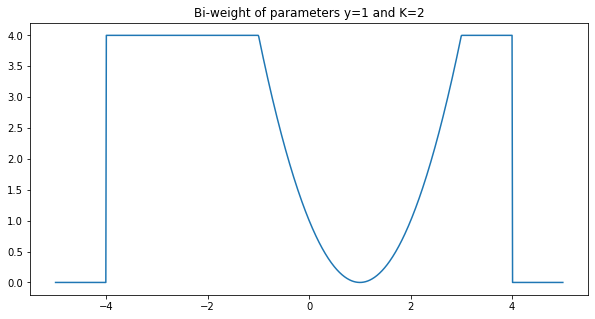

In [10]:
bi_weight = BiWeight(1, 2, -4, 4)
t = np.linspace(-5, 5, 1000)
y = np.array([bi_weight(x) for x in t])
plt.figure(figsize=(10, 5))
plt.plot(t, y)
plt.title("Bi-weight of parameters y=1 and K=2")
plt.show()

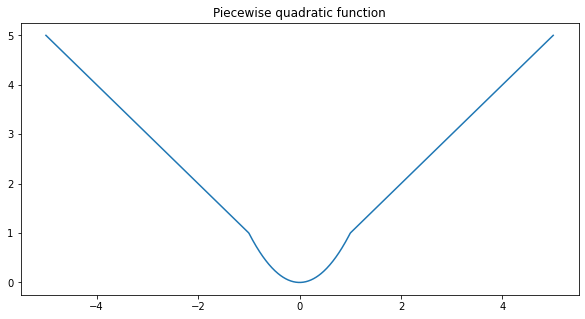

In [12]:
polynom = PiecewiseQuadratic([(-10,-1),(-1,1),(1,10)], [[-1,0],[1,0,0],[1,0]])
t = np.linspace(-5, 5, 1000)
y = np.array([polynom(x) for x in t])
plt.figure(figsize=(10, 5))
plt.plot(t, y)
plt.title("Piecewise quadratic function")
plt.show()

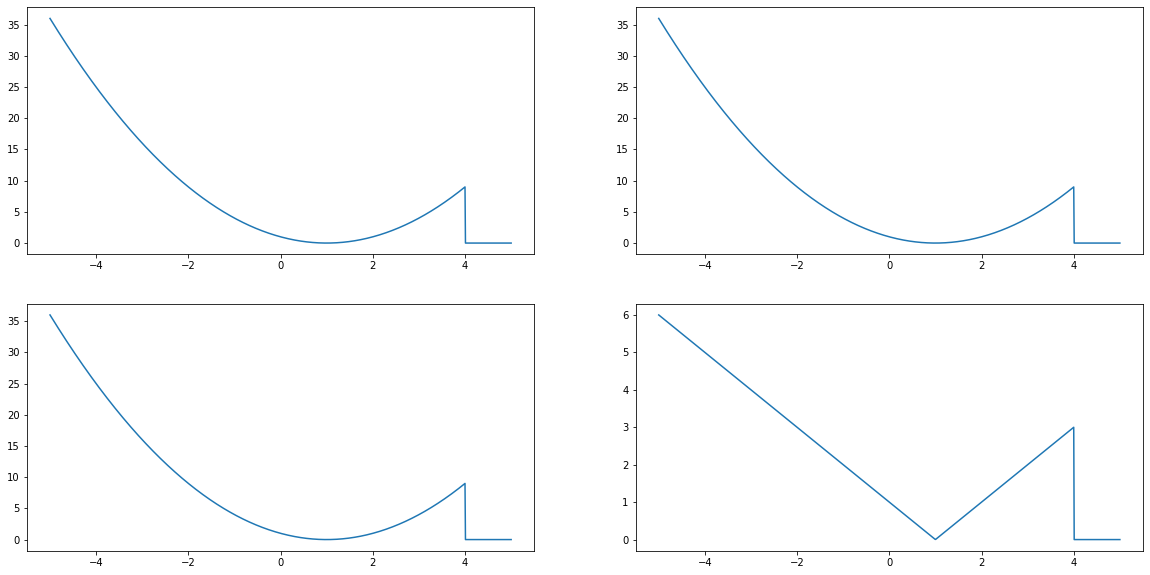

In [13]:
t = np.linspace(-5, 5, 1000)
fig, ax = plt.subplots(2, 2, figsize=(20, 10))

loss = BiWeight(1, 7, -6, 4)
y = np.array([loss(x) for x in t])
ax[0, 0].plot(t, y)

loss = Huber(1, 7, -6, 4)
y = np.array([loss(x) for x in t])
ax[0, 1].plot(t, y)

loss = L2Loss(1, -6, 4)
y = np.array([loss(x) for x in t])
ax[1, 0].plot(t, y)

loss = L1Loss(1, -6, 4)
y = np.array([loss(x) for x in t])
ax[1, 1].plot(t, y)

plt.show()

### Changepoint detection tests

  0%|          | 0/6 [00:00<?, ?it/s]

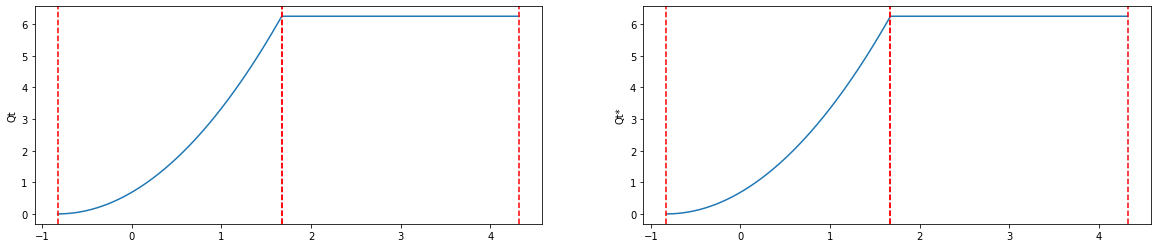

 17%|█▋        | 1/6 [00:00<00:01,  4.72it/s]

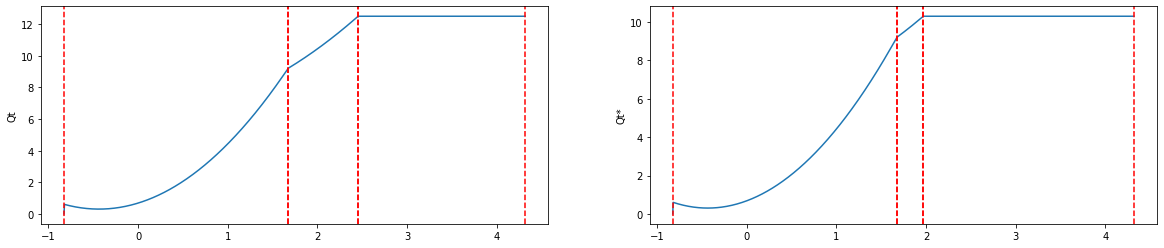

 33%|███▎      | 2/6 [00:00<00:00,  4.83it/s]

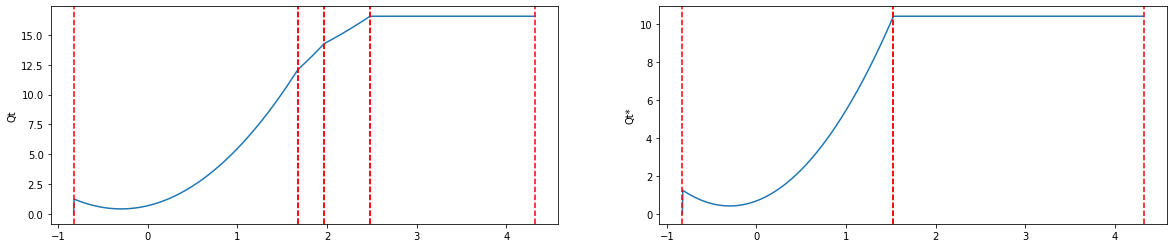

 50%|█████     | 3/6 [00:00<00:00,  4.44it/s]

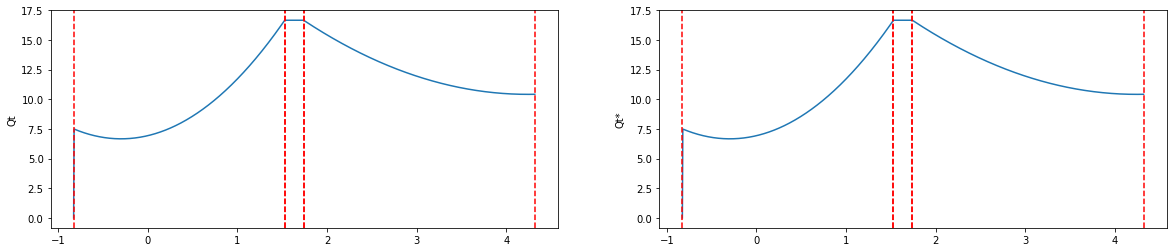

 67%|██████▋   | 4/6 [00:00<00:00,  4.32it/s]

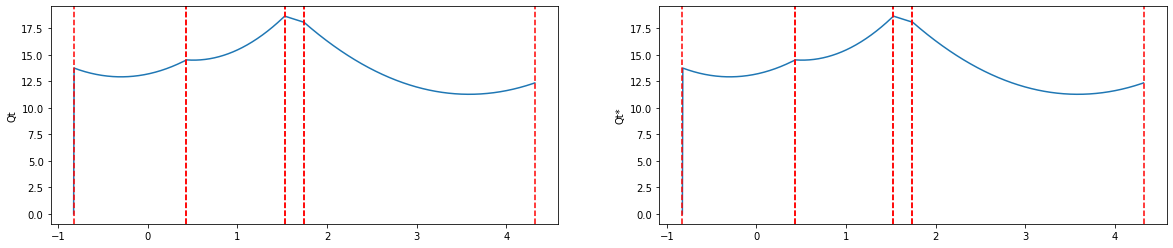

 83%|████████▎ | 5/6 [00:01<00:00,  4.30it/s]

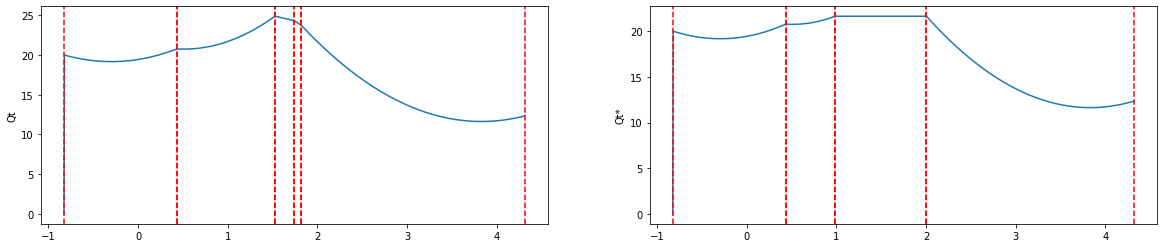

100%|██████████| 6/6 [00:01<00:00,  4.42it/s]


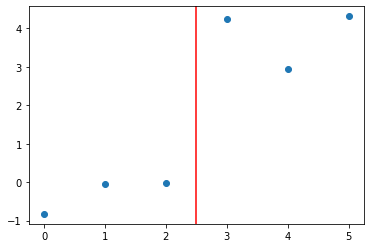

In [28]:
y1 = np.zeros(3)
y2 = 3+np.ones(3)
y = np.concatenate((y1, y2))
y += np.random.normal(0, 0.5, len(y))

K = 2.5
loss = BiWeight(0, 2.5, 0, 0)

cp = rfpop(y, loss, 10, verbose=True)
taus = [elt[1] for elt in cp]

plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

  0%|          | 0/24 [00:00<?, ?it/s]

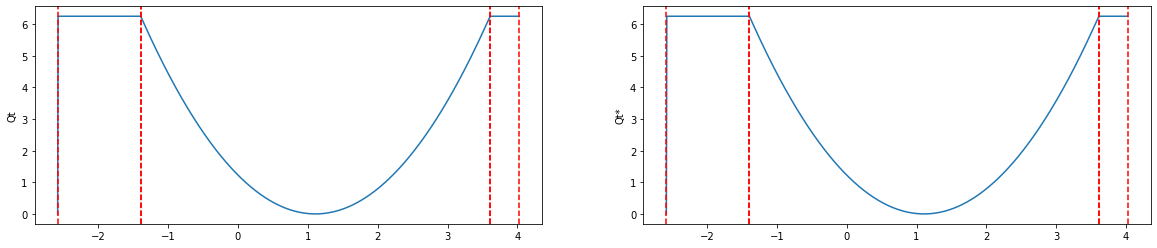

  4%|▍         | 1/24 [00:00<00:05,  3.92it/s]

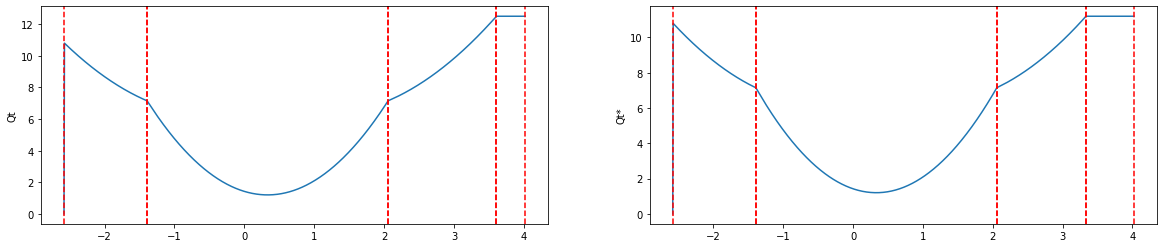

  8%|▊         | 2/24 [00:00<00:05,  4.25it/s]

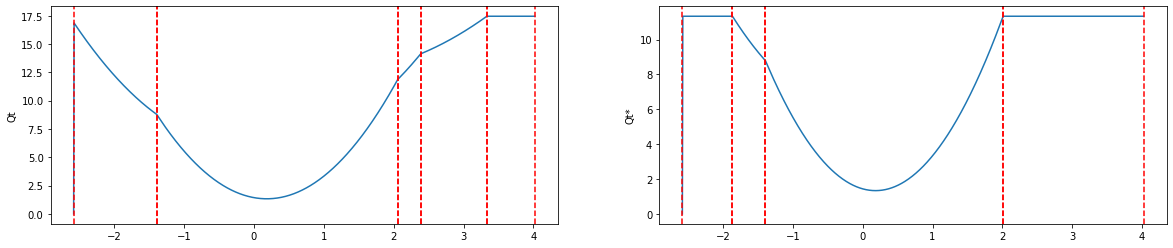

 12%|█▎        | 3/24 [00:00<00:04,  4.29it/s]

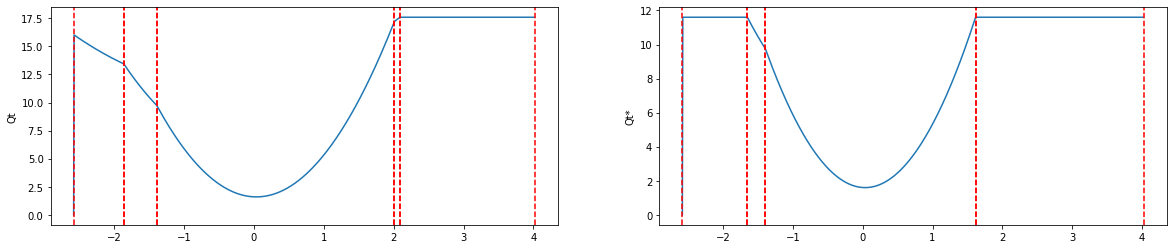

 17%|█▋        | 4/24 [00:00<00:05,  3.92it/s]

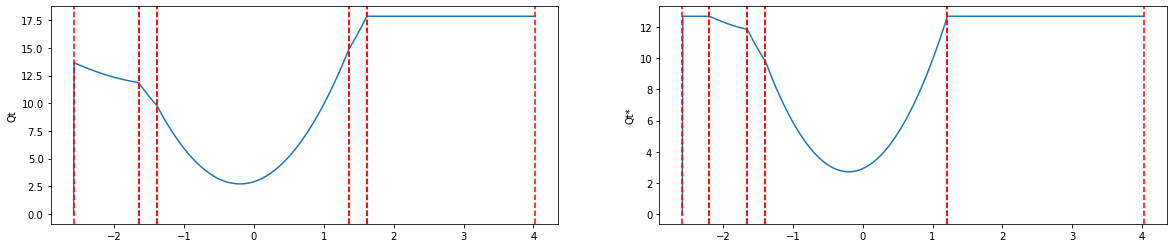

 21%|██        | 5/24 [00:01<00:06,  2.85it/s]

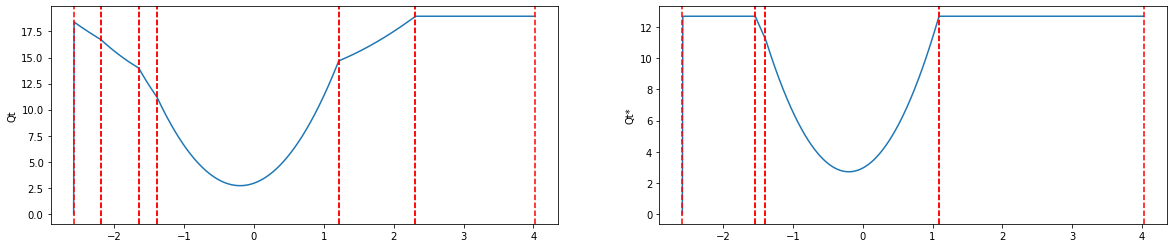

 25%|██▌       | 6/24 [00:01<00:05,  3.17it/s]

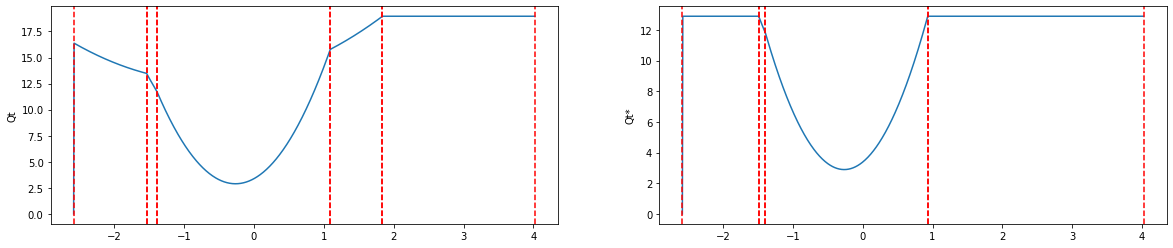

 29%|██▉       | 7/24 [00:02<00:04,  3.44it/s]

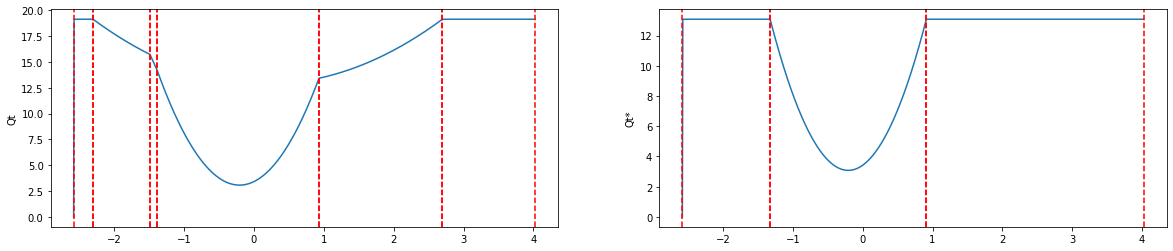

 33%|███▎      | 8/24 [00:02<00:04,  3.59it/s]

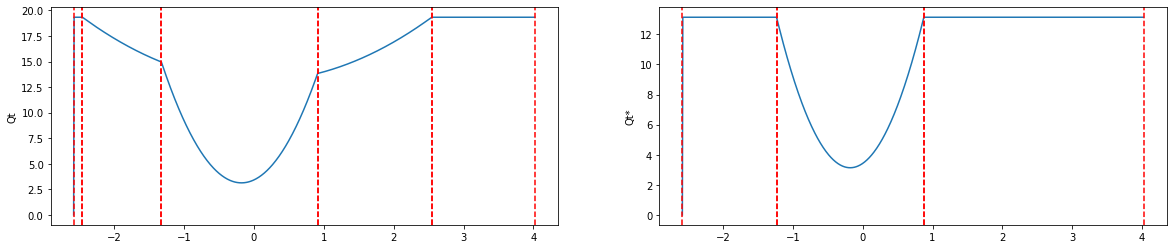

 38%|███▊      | 9/24 [00:02<00:04,  3.73it/s]

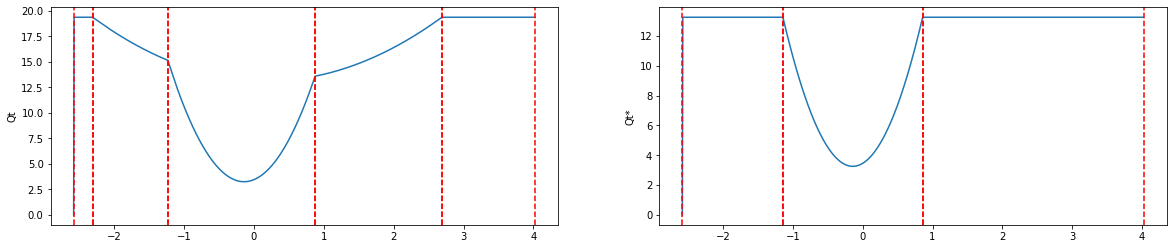

 42%|████▏     | 10/24 [00:02<00:03,  3.83it/s]

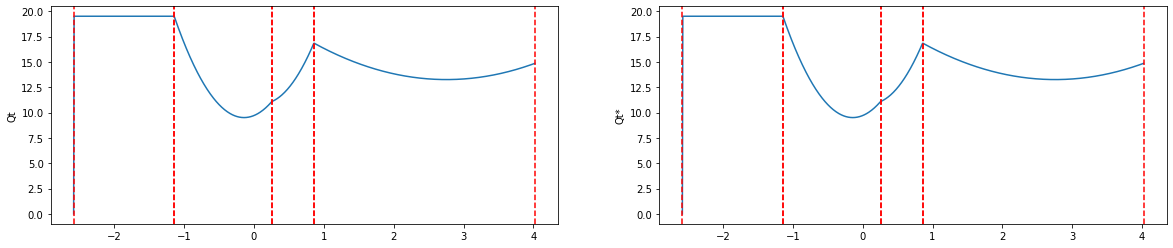

 46%|████▌     | 11/24 [00:02<00:03,  3.87it/s]

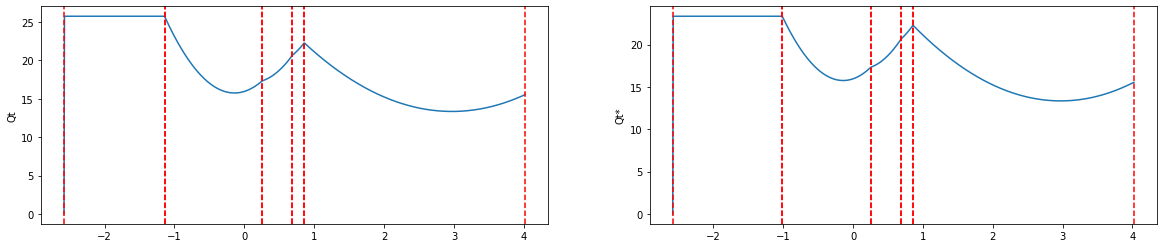

 50%|█████     | 12/24 [00:03<00:03,  3.91it/s]

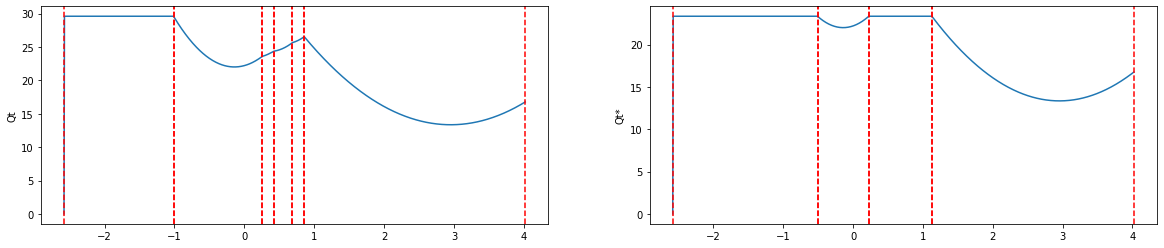

 54%|█████▍    | 13/24 [00:03<00:02,  4.02it/s]

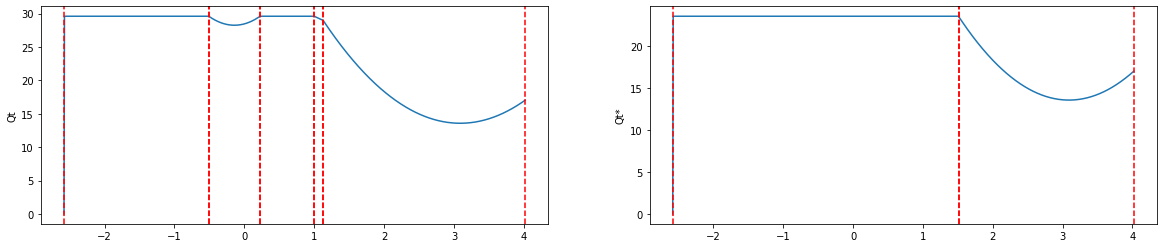

 58%|█████▊    | 14/24 [00:03<00:02,  3.46it/s]

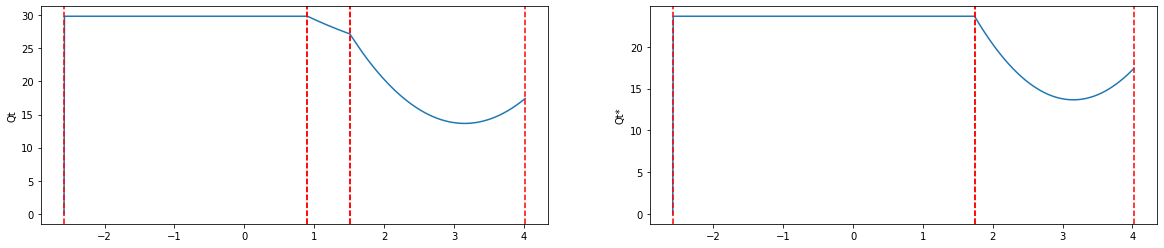

 62%|██████▎   | 15/24 [00:04<00:02,  3.66it/s]

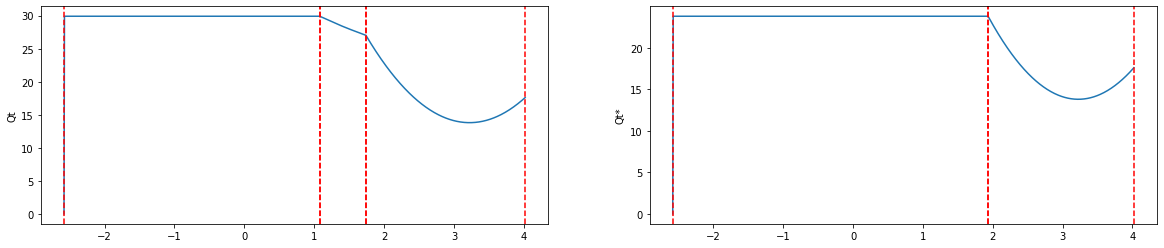

 67%|██████▋   | 16/24 [00:04<00:02,  3.88it/s]

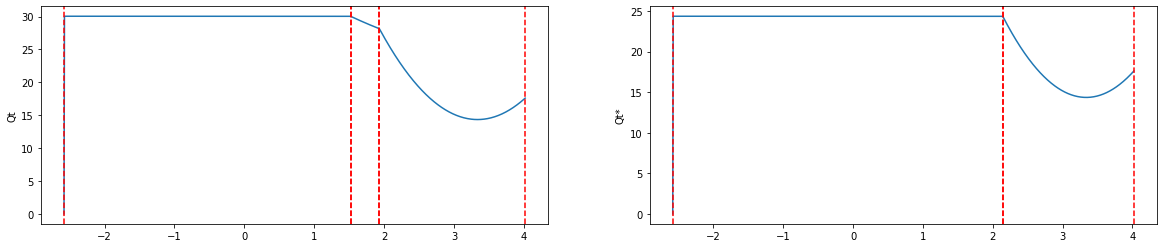

 71%|███████   | 17/24 [00:04<00:01,  4.01it/s]

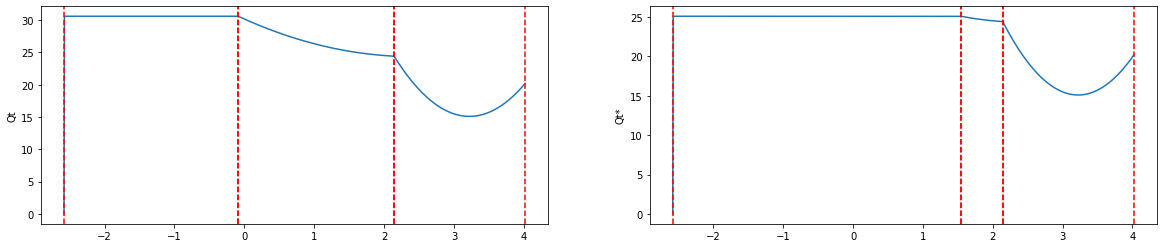

 75%|███████▌  | 18/24 [00:04<00:01,  4.08it/s]

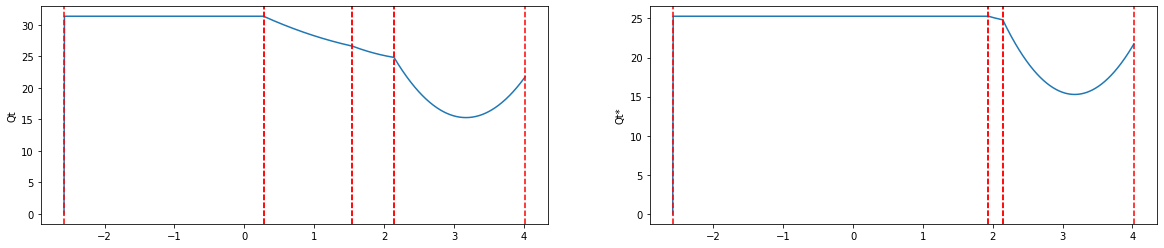

 79%|███████▉  | 19/24 [00:05<00:01,  4.02it/s]

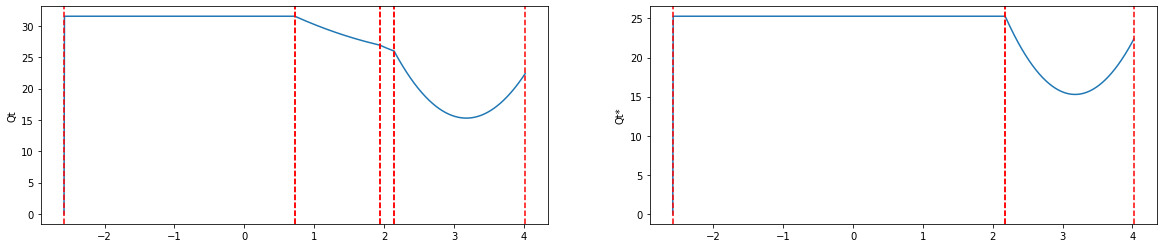

 83%|████████▎ | 20/24 [00:05<00:00,  4.22it/s]

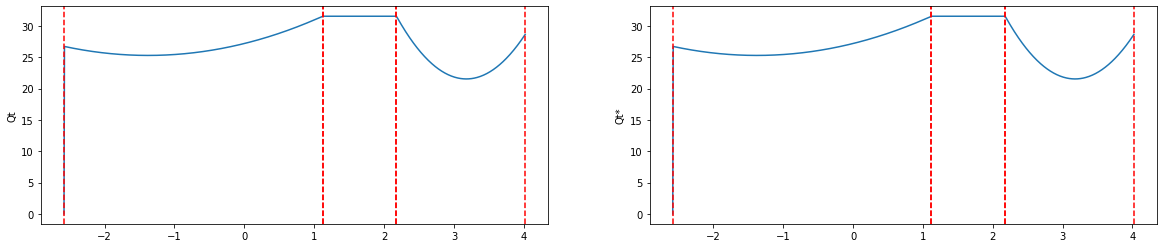

 88%|████████▊ | 21/24 [00:05<00:00,  4.39it/s]

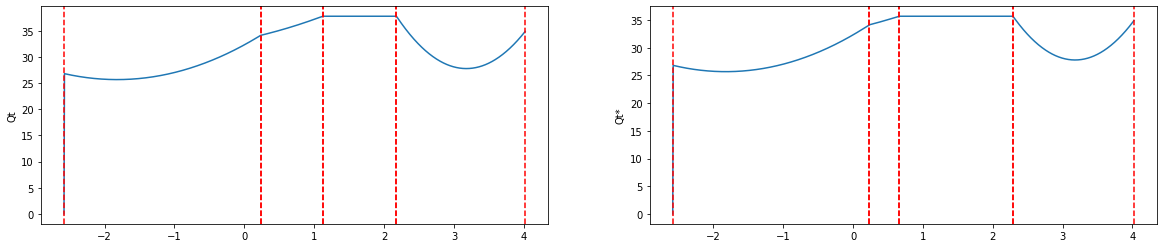

 92%|█████████▏| 22/24 [00:05<00:00,  4.32it/s]

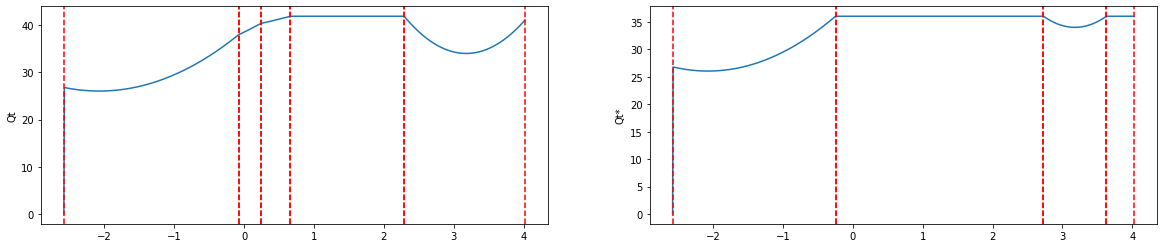

 96%|█████████▌| 23/24 [00:06<00:00,  3.71it/s]

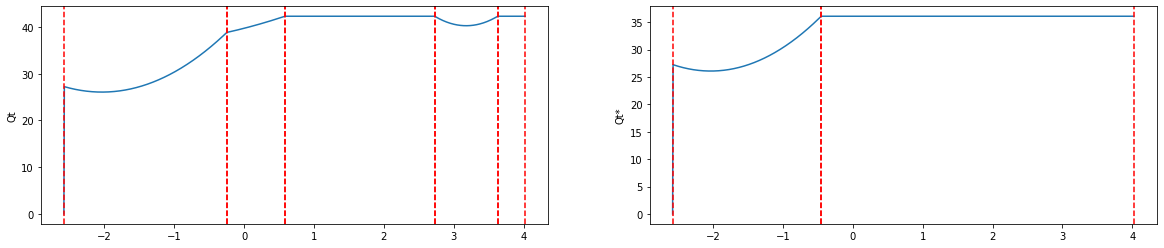

100%|██████████| 24/24 [00:06<00:00,  3.81it/s]


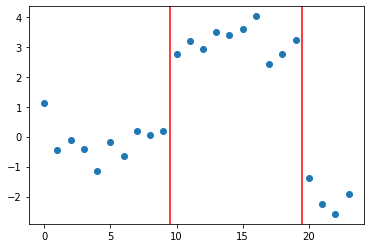

In [23]:
y1 = np.zeros(10)
y2 = 3+np.zeros(10)
y3 = -2+np.zeros(4)
y = np.concatenate((y1, y2, y3))
y += np.random.normal(0, 0.5, len(y))

K = 2.5
loss = BiWeight(0, 2.5, 0, 0)

cp = rfpop(y, loss, 10, verbose=True)
taus = [elt[1] for elt in cp]

plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

100%|██████████| 24/24 [00:00<00:00, 2726.89it/s]


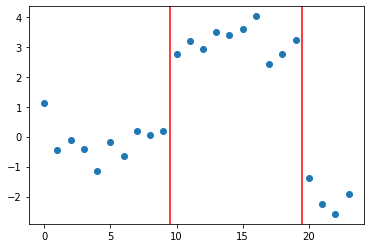

100%|██████████| 24/24 [00:00<00:00, 2997.27it/s]


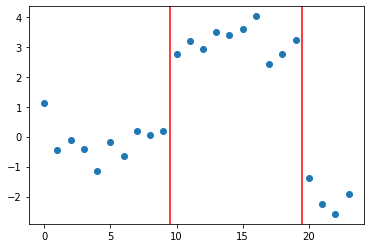

100%|██████████| 24/24 [00:00<00:00, 1333.89it/s]


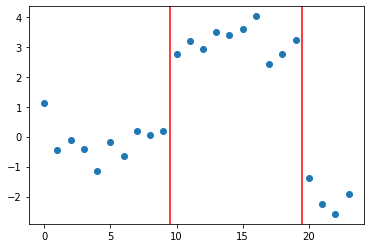

In [26]:
loss = BiWeight(0, K, 0, 0)

cp = rfpop(y, loss, 10, verbose=False)
taus = [elt[1] for elt in cp]

plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

loss = L2Loss(0, 0, 0)

cp = rfpop(y, loss, 10, verbose=False)
taus = [elt[1] for elt in cp]

plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

loss = L1Loss(0, 0, 0)

cp = rfpop(y, loss, 10, verbose=False)
taus = [elt[1] for elt in cp]

plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

100%|██████████| 170/170 [00:00<00:00, 2116.66it/s]


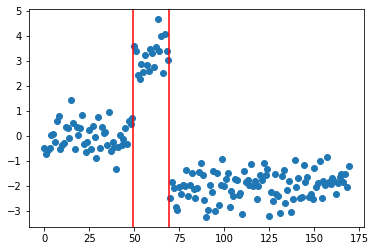

100%|██████████| 170/170 [00:00<00:00, 2266.41it/s]


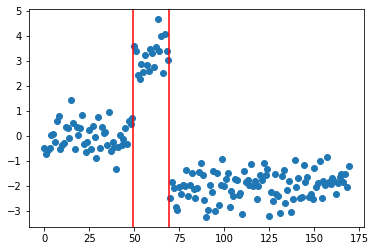

100%|██████████| 170/170 [00:00<00:00, 2799.96it/s]


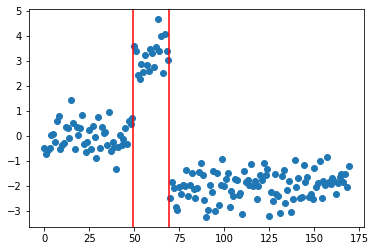

100%|██████████| 170/170 [00:00<00:00, 489.89it/s]


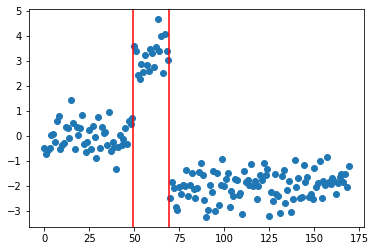

In [20]:
y1 = np.zeros(50)
y2 = 3+np.zeros(20)
y3 = -2+np.zeros(100)
y = np.concatenate((y1, y2, y3))
y += np.random.normal(0, 0.5, len(y))

loss = BiWeight(0, 2.5, 0, 0)
cp = rfpop(y, loss, 10)
taus = [elt[1] for elt in cp]
plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

loss = Huber(0, 2.5, 0, 0)
cp = rfpop(y, loss, 10)
taus = [elt[1] for elt in cp]
plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

loss = L2Loss(0, 0, 0)
cp = rfpop(y, loss, 10)
taus = [elt[1] for elt in cp]
plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

loss = L1Loss(0, 0, 0)
cp = rfpop(y, loss, 10)
taus = [elt[1] for elt in cp]
plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

100%|██████████| 450/450 [00:00<00:00, 2209.59it/s]


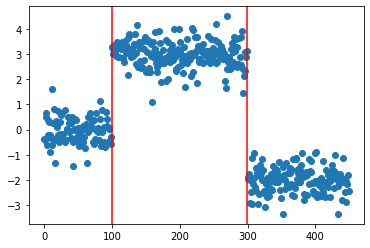

100%|██████████| 450/450 [00:00<00:00, 2184.25it/s]


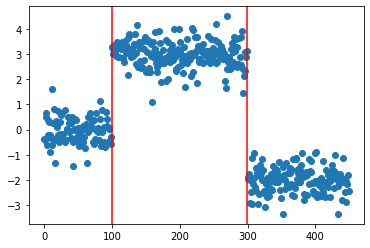

100%|██████████| 450/450 [00:00<00:00, 2660.20it/s]


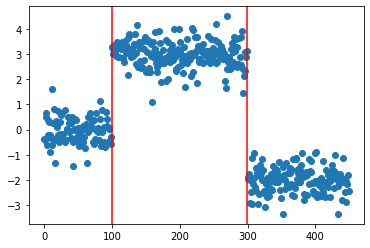

100%|██████████| 450/450 [00:01<00:00, 297.43it/s]


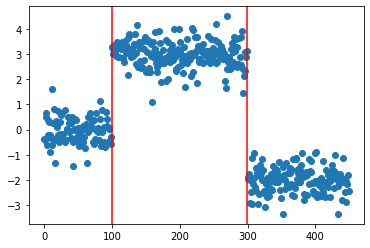

In [21]:
y1 = np.zeros(100)
y2 = 3+np.zeros(200)
y3 = -2+np.zeros(150)
y = np.concatenate((y1, y2, y3))
y += np.random.normal(0, 0.5, len(y))


loss = BiWeight(0, 2.5, 0, 0)
cp = rfpop(y, loss, 10)
taus = [elt[1] for elt in cp]
plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

loss = Huber(0, 2.5, 0, 0)
cp = rfpop(y, loss, 10)
taus = [elt[1] for elt in cp]
plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

loss = L2Loss(0, 0, 0)
cp = rfpop(y, loss, 10)
taus = [elt[1] for elt in cp]
plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

loss = L1Loss(0, 0, 0)
cp = rfpop(y, loss, 10)
taus = [elt[1] for elt in cp]
plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

100%|██████████| 45000/45000 [00:29<00:00, 1501.05it/s]


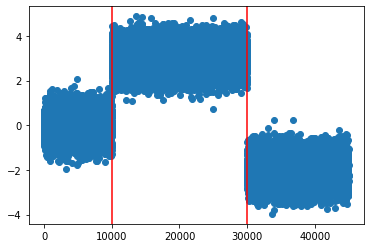

In [16]:
y1 = np.zeros(10000)
y2 = 3+np.zeros(20000)
y3 = -2+np.zeros(15000)
y = np.concatenate((y1, y2, y3))
y += np.random.normal(0, 0.5, len(y))
cp = rfpop(y, 2.5, 10)
taus = [elt[1] for elt in cp]

plt.figure()
bkpts = get_breakpoints(taus)
plt.scatter(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()